# Projecting a language model onto a lookback HMM, by streaming

A neural language model is an opaque, autoregressive density over text. A hidden Markov model is the
opposite: a transparent, finite-state generative story. This notebook does **variational projection** --
it finds the HMM closest to a language model in KL divergence, distilling the LM into something we can read.

Three ideas make it work and make it interesting:

* **The projection is a KL minimisation.** Minimising the forward KL `KL(LM || HMM)` is the same as
  maximising `E_LM[log HMM(X)]` -- i.e. fitting the HMM by maximum likelihood on *samples drawn from the
  LM*. That is exactly what EM does.
* **A *lookback* HMM, not a vanilla one.** `mixle`'s `LookbackHiddenMarkovModelDistribution` lets each
  hidden state's emission condition on the previous `lag` tokens. With `lag=1`, each state carries its own
  token **bigram** model -- a Markov-switching mixture of n-grams, far closer to a language model than a
  memoryless HMM.
* **Streaming, because the LM is an infinite generator.** Rather than fit a fixed batch, we draw fresh LM
  samples forever and fold them into a running set of sufficient statistics, re-estimating as we go -- so
  the HMM keeps improving as it sees more of the LM's distribution, at constant memory.

The "LM" is a small char-level GRU we train in-notebook on Homer's *Iliad* -- anything sampleable
(distilGPT-2, an n-gram model, ...) plugs in identically; you only need to draw token sequences from it.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import re, io, time
import numpy as np, torch, torch.nn as nn
import matplotlib.pyplot as plt
from mixle.stats import (IntegerCategoricalEstimator, CategoricalEstimator, IntegerMarkovChainEstimator,
                        SequenceEstimator)
from mixle.stats.latent.hidden_markov import HiddenMarkovEstimator
from mixle.stats.latent.lookback_hidden_markov_model import LookbackHiddenMarkovModelEstimator
from mixle.inference.estimation import optimize

rng = np.random.RandomState(0); torch.manual_seed(0)
def panel(ncol=1, w=5.0, h=3.0):
    fig, ax = plt.subplots(1, ncol, figsize=(w * ncol, h)); return fig, (ax if ncol > 1 else [ax])
print('variational projection LM -> lookback HMM, fit by streaming EM')

variational projection LM -> lookback HMM, fit by streaming EM


## 1. A small language model

We train a one-layer char-level GRU on ~200k characters of the *Iliad* -- a genuine (if small) language
model over a 33-symbol alphabet. Char-level keeps the alphabet tiny, which matters later: a lookback HMM's
emission table grows as `vocab^(lag+1)`. After a few hundred steps it generates recognisably Homeric
nonsense, and its cross-entropy in **bits per character** is the floor any approximation is measured
against.

corpus 200000 chars; alphabet V=33: ' !,.:;?abcdefghijklmnopqrstuvwxyz'


trained 500 steps in 10s; final 2.08 bits/char


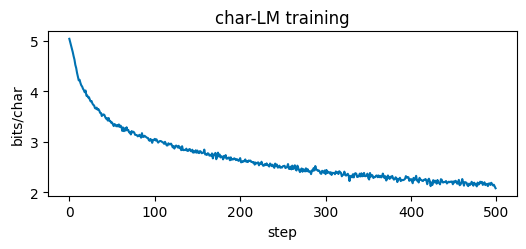

LM sample: 'taven graeans, mathers and kneer, an to your pliused hive held that in the pean before thi'


In [2]:
txt = open('../../data/iliad/iliad_en.txt', encoding='utf-8', errors='ignore').read().lower()
txt = re.sub(r"[^a-z .,;:!?'\n]", ' ', txt); txt = re.sub(r'[ \n]+', ' ', txt)[:200000]
chars = sorted(set(txt)); V = len(chars); stoi = {c: i for i, c in enumerate(chars)}; itos = {i: c for c, i in stoi.items()}
ids = np.array([stoi[c] for c in txt], dtype=np.int64); SP = stoi[' ']
print(f'corpus {len(txt)} chars; alphabet V={V}: {"".join(chars)!r}')

class CharLM(nn.Module):
    def __init__(s): super().__init__(); s.e = nn.Embedding(V, 48); s.g = nn.GRU(48, 160, batch_first=True); s.o = nn.Linear(160, V)
    def forward(s, x, h=None): z, h = s.g(s.e(x), h); return s.o(z), h
lm = CharLM(); opt = torch.optim.Adam(lm.parameters(), 1e-3); Lt = 96
def tbatch(bs=64):
    j = rng.randint(0, len(ids) - Lt - 1, bs)
    return (torch.tensor(np.stack([ids[k:k + Lt] for k in j])), torch.tensor(np.stack([ids[k + 1:k + Lt + 1] for k in j])))
t0 = time.time(); losses = []
for step in range(500):
    X, Y = tbatch(); logit, _ = lm(X); loss = nn.functional.cross_entropy(logit.reshape(-1, V), Y.reshape(-1))
    opt.zero_grad(); loss.backward(); opt.step(); losses.append(loss.item() / np.log(2))
print(f'trained 500 steps in {time.time()-t0:.0f}s; final {losses[-1]:.2f} bits/char')

@torch.no_grad()
def lm_sample(n, L=55, temp=1.0):
    out = []
    for _ in range(n):
        h = None; x = torch.tensor([[SP]]); s = []
        for _ in range(L):
            logit, h = lm(x, h); p = torch.softmax(logit[0, -1] / temp, -1)
            nxt = int(torch.multinomial(p, 1)); s.append(nxt); x = torch.tensor([[nxt]])
        out.append(s)
    return out
@torch.no_grad()
def lm_bits_per_char(seqs):
    tot_ll, tot = 0.0, 0
    for s in seqs:
        x = torch.tensor([[SP] + s[:-1]]); logit, _ = lm(x); lp = torch.log_softmax(logit[0], -1)
        tot_ll += float(lp[np.arange(len(s)), s].sum()); tot += len(s)
    return -tot_ll / tot / np.log(2)

fig, ax = panel(1, 5.5, 2.6); ax[0].plot(losses, color='#0072B2'); ax[0].set(xlabel='step', ylabel='bits/char', title='char-LM training')
plt.tight_layout(); plt.show()
print('LM sample:', repr(''.join(itos[i] for i in lm_sample(1, 90)[0])))

## 2. The target family: a lookback HMM

The HMM we project onto has `K` hidden states that evolve by a Markov transition; at each step the active
state emits the next character. With **`lag=1`** the emission is a per-state token Markov chain
(`IntegerMarkovChain`) -- so state *k* is a bigram model `p(char_t | char_{t-1})`, and the latent chain
switches between them. A vanilla HMM (`lag=0`) instead emits each character from a state-specific
*unigram*. Two details matter for a *correct* fit: every emission needs a smoothing pseudo-count (or a
held-out character gets probability zero and perplexity is infinite), and EM must run long enough to
**break the symmetry between states** -- a too-short fit leaves all states identical and the extra capacity
unused.

In [3]:
def make_estimator(K, lag):
    # an HMM estimator over char sequences: lag=0 -> unigram emissions, lag>=1 -> per-state n-gram emissions
    length = CategoricalEstimator(pseudo_count=0.5)
    if lag == 0:
        return HiddenMarkovEstimator([IntegerCategoricalEstimator(pseudo_count=0.5) for _ in range(K)], len_estimator=length)
    init = SequenceEstimator(IntegerCategoricalEstimator(pseudo_count=0.2), len_estimator=CategoricalEstimator(pseudo_count=0.2))
    return LookbackHiddenMarkovModelEstimator(
        [IntegerMarkovChainEstimator(V, lag=lag, pseudo_count=0.5) for _ in range(K)],
        lag=lag, init_estimators=[init] * K, len_estimator=length, pseudo_count=(1.0, 1.0))

def bits_per_char(model, seqs):
    enc = model.dist_to_encoder().seq_encode(seqs)
    return -float(np.sum(model.seq_log_density(enc))) / sum(len(s) for s in seqs) / np.log(2)
print('estimator builder ready (lag=0 vanilla HMM, lag=1 Markov-switching bigrams; smoothed emissions)')

estimator builder ready (lag=0 vanilla HMM, lag=1 Markov-switching bigrams; smoothed emissions)


## 3. Streaming the projection

The loop holds a model and a **running accumulator** of sufficient statistics. We first **warm-start** with
a short batch EM -- enough iterations to break state symmetry so the states are distinct. Then each step we
draw a fresh batch *from the LM*, run one E-step against the current model, fold the result into the running
accumulator, and re-estimate. This is online EM over an unbounded stream -- the forward-KL projection
`KL(LM || HMM)` estimated with fresh Monte-Carlo samples at every step, never holding the full dataset.
(A short alphabet-coverage primer keeps every symbol in the support as the stream grows.)

the LM's own cross-entropy on held-out samples: 2.38 bits/char (the projection floor)


streamed 1120 LM sequences in 4s


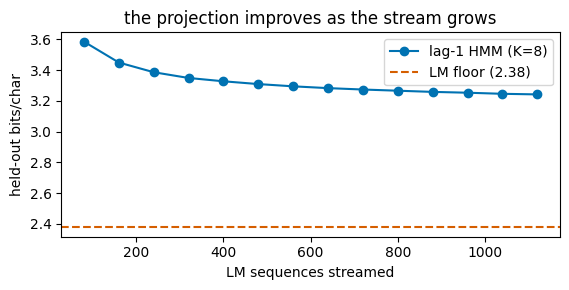

lookback HMM after streaming: 3.24 bits/char  (LM floor 2.38; gap = projection loss)


In [4]:
HELD = lm_sample(80, 55, temp=1.0)                       # a fixed held-out set drawn from the LM
LM_BPC = lm_bits_per_char(HELD)                          # the LM's own entropy on it -- the floor
print(f"the LM's own cross-entropy on held-out samples: {LM_BPC:.2f} bits/char (the projection floor)")

COVER = [[c, c] for c in range(V)]                       # one of every symbol: keeps the support stable
def stream_project(K, lag, n_chunks=14, chunk=80, warm=300, warm_its=30, record=False, seed=0):
    est = make_estimator(K, lag); r = np.random.RandomState(seed)
    model = optimize(lm_sample(warm, 55) + COVER, est, max_its=warm_its, rng=r, out=io.StringIO())  # break state symmetry
    run = est.accumulator_factory().make()
    a0 = est.accumulator_factory().make()
    a0.seq_update(model.dist_to_encoder().seq_encode(COVER), np.ones(len(COVER)), model); run.combine(a0.value())
    curve = []
    for _ in range(n_chunks):
        batch = lm_sample(chunk, 55)                     # fresh LM samples -- the infinite stream
        acc = est.accumulator_factory().make()
        acc.seq_update(model.dist_to_encoder().seq_encode(batch), np.ones(len(batch)), model)
        run.combine(acc.value()); model = est.estimate(None, run.value())
        if record: curve.append(bits_per_char(model, HELD))
    return model, curve

t0 = time.time(); hmm, curve = stream_project(K=8, lag=1, n_chunks=14, record=True)
print(f'streamed {14*80} LM sequences in {time.time()-t0:.0f}s')
fig, ax = panel(1, 5.8, 3.0)
ax[0].plot(np.arange(1, len(curve) + 1) * 80, curve, '-o', color='#0072B2', label='lag-1 HMM (K=8)')
ax[0].axhline(LM_BPC, color='#D55E00', ls='--', label=f'LM floor ({LM_BPC:.2f})')
ax[0].set(xlabel='LM sequences streamed', ylabel='held-out bits/char', title='the projection improves as the stream grows')
ax[0].legend(); plt.tight_layout(); plt.show()
print(f'lookback HMM after streaming: {curve[-1]:.2f} bits/char  (LM floor {LM_BPC:.2f}; gap = projection loss)')

## 4. How much of the LM can a finite-state model capture?

The projection is lossy by construction -- the LM has unbounded context, the HMM has `K` states and a
`lag`-token window. Two sweeps locate the loss. **Lookback**: a per-state *bigram* emission (`lag=1`)
captures the short-range structure a unigram (`lag=0`) cannot -- a large drop. **States**: more hidden
states give a better fit, each one carving off another mode of the LM's local behaviour, with the gains
flattening once a handful of states is reached (and, because EM has local optima, we take the best of a
couple of restarts at each `K`). The remaining gap to the LM floor is the long-range context a finite-state
model simply cannot represent.

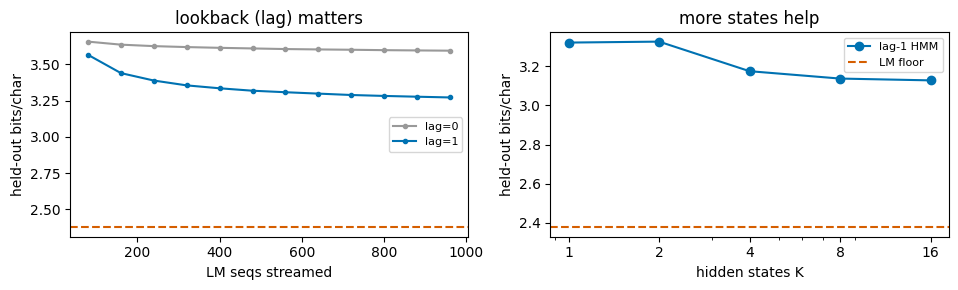

bits/char by states: {1: np.float64(3.32), 2: np.float64(3.33), 4: np.float64(3.18), 8: np.float64(3.14), 16: np.float64(3.13)}


In [5]:
fig, ax = panel(2, 4.8, 3.0)
for lag, c in [(0, '#999'), (1, '#0072B2')]:
    _, cv = stream_project(K=8, lag=lag, n_chunks=12, record=True)
    ax[0].plot(np.arange(1, len(cv) + 1) * 80, cv, '-o', ms=3, color=c, label=f'lag={lag}')
ax[0].axhline(LM_BPC, color='#D55E00', ls='--'); ax[0].set(xlabel='LM seqs streamed', ylabel='held-out bits/char', title='lookback (lag) matters'); ax[0].legend(fontsize=8)
Ks = [1, 2, 4, 8, 16]; final = []
for K in Ks:                                                          # EM has local optima -> best of 2 restarts per K
    final.append(min(bits_per_char(stream_project(K=K, lag=1, n_chunks=20, seed=s)[0], HELD) for s in (0, 1)))
ax[1].plot(Ks, final, '-o', color='#0072B2', label='lag-1 HMM'); ax[1].axhline(LM_BPC, color='#D55E00', ls='--', label='LM floor')
ax[1].set(xlabel='hidden states K', ylabel='held-out bits/char', title='more states help', xscale='log'); ax[1].set_xticks(Ks); ax[1].set_xticklabels(Ks); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print('bits/char by states:', dict(zip(Ks, np.round(final, 2))))

## 5. Reading the distilled states

This is the payoff of projecting onto something interpretable. Each hidden state of the `lag=1` HMM *is* a
character bigram model, so we can simply **sample from it** to hear its voice and read off its preferred
characters. The states differ in their local textures and favoured transitions -- a legible decomposition
of the LM's short-range behaviour that you could never read off the GRU's weights.

a sample of the bigram "voice" of each distilled hidden state:

  state 0:  'nrongoftydrmjx,! ottyrks odwkhisen opownegq!os'
  state 1:  'go be ambone t pem asthers aer gren ro swher h'
  state 2:  'h kim end nof doves idad n cedeat immbery rele'
  state 3:  'the, we an sheme the theand musithe the me her'
  state 4:  'ycwmjaw hirdowap m y.wnn aparins, dckinederd, '
  state 5:  'fravelomae tido ihine, gd dtuf for m miwerst i'
  state 6:  'veu!.mkgenhrkmozugvu!qtrqk:yfarzbpmqxecgrrgzhf'
  state 7:  ':shrzkj,bjptf,cwaix nyalw:krpiakfifusdlcifofiq'


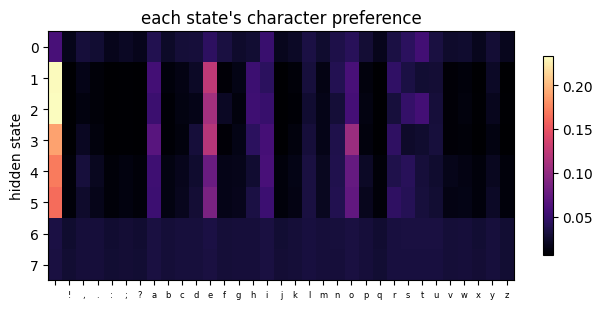

In [6]:
def state_voice(markov, n=42, seed=0):
    r = np.random.RandomState(seed); cond = np.asarray(markov.cond_dist); prev = SP; out = []
    for _ in range(n):
        nxt = r.choice(V, p=cond[prev] / cond[prev].sum()); out.append(itos[nxt]); prev = nxt
    return ''.join(out)
hmm8, _ = stream_project(K=8, lag=1, n_chunks=14)
print('a sample of the bigram "voice" of each distilled hidden state:\n')
for k, topic in enumerate(hmm8.topics):
    print(f'  state {k}:  {state_voice(topic, 46, seed=k)!r}')
fig, ax = panel(1, 6.5, 3.2)
pref = np.array([np.asarray(t.cond_dist).mean(0) for t in hmm8.topics])  # avg next-char dist per state
im = ax[0].imshow(pref, aspect='auto', cmap='magma'); ax[0].set_xticks(range(V)); ax[0].set_xticklabels(chars, fontsize=6)
ax[0].set(yticks=range(len(hmm8.topics)), ylabel='hidden state', title="each state's character preference")
plt.colorbar(im, ax=ax[0], shrink=0.8); plt.tight_layout(); plt.show()

## 6. Streaming vs batch: coverage at constant memory

Streaming trades a little optimisation quality for memory: its running sufficient statistics are a constant
size (the transition tables) no matter how many sequences flow through, while a full-batch refit must hold
every sequence at once. Run with the same EM effort, the streamed projection tracks the batch fit closely
and converges to it as the stream grows -- so we get batch-quality distillation over an unbounded supply of
LM samples without ever materialising them.

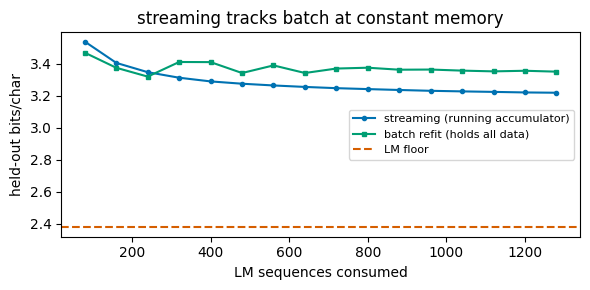

In [7]:
_, stream_curve = stream_project(K=8, lag=1, n_chunks=16, chunk=80, record=True, seed=1)
sizes = np.arange(1, 17) * 80; batch_curve = []
for ntot in sizes:
    est = make_estimator(8, 1)
    m = optimize(lm_sample(int(ntot), 55) + COVER, est, max_its=25, rng=np.random.RandomState(2), out=io.StringIO())
    batch_curve.append(bits_per_char(m, HELD))
fig, ax = panel(1, 6.0, 3.0)
ax[0].plot(sizes, stream_curve, '-o', ms=3, color='#0072B2', label='streaming (running accumulator)')
ax[0].plot(sizes, batch_curve, '-s', ms=3, color='#009E73', label='batch refit (holds all data)')
ax[0].axhline(LM_BPC, color='#D55E00', ls='--', label='LM floor')
ax[0].set(xlabel='LM sequences consumed', ylabel='held-out bits/char', title='streaming tracks batch at constant memory'); ax[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

## In short

We distilled a small language model into a finite-state model we can read, by **variational projection**:

* minimising the forward KL `KL(LM || HMM)` is maximum-likelihood of the HMM on samples drawn from the LM,
  so EM does the projection;
* the target is a **lookback HMM** (`lag=1`) -- a Markov-switching mixture of character **bigram** models,
  far closer to an LM than a memoryless HMM;
* we fit it by **streaming** EM over an unbounded supply of LM samples, after a warm-start long enough to
  break state symmetry, so the model improves at constant memory and tracks a full-batch fit;
* both a longer **lookback** and more **states** close the gap; what remains is the long-range context a
  finite-state model cannot hold -- the honest bits-per-character distance from the LM's own entropy.

Getting the fit *correct* mattered: a flat states-curve was the tell that the states had collapsed (a
too-short warm-start) and that the unigram baseline was assigning zero probability (no emission
smoothing) -- both fixed here. This also fixed a `mixle` bug along the way:
`IntegerMarkovChainEstimator` was re-inferring its support from each shard and shrinking it, which broke
streaming whenever a batch missed a rare character; it now honours the declared `num_values`.

## References

* Rabiner, L. (1989). A tutorial on hidden Markov models. *Proc. IEEE* 77(2).
* Hinton, G., Vinyals, O., Dean, J. (2015). Distilling the knowledge in a neural network. -- projection as
  distillation.
* Cappe, O., Moulines, E. (2009). Online EM for latent data models. *JRSS-B* 71(3). -- streaming EM.

## Exercises and extensions

1. **Higher lag.** Push to `lag=2` (per-state trigram emissions) on a *smaller* alphabet and measure the
   bits/char gain against the emission-table blow-up `vocab^(lag+1)`.
2. **A real LM.** Swap the GRU for distilGPT-2 (character-retokenised) and project it; how much more of a
   real LM does the lookback HMM miss?
3. **Reverse KL.** Fit by `KL(HMM || LM)` instead -- sample from the HMM, score under the LM -- and compare
   the mode-seeking vs mass-covering behaviour of the two projections.
4. **Decay vs accumulation.** Replace the running accumulator with `StreamingEstimator`'s decay schedule and
   study the stability/recency trade-off as the LM (or its temperature) drifts.